In [1]:
# import packages
import numpy as np
import pandas as pd
import seaborn as sb
import glob 
import tensorflow
import keras

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-pastel')

c:\Users\hetpe\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Step 1: merge all the participant files from 1C

In [2]:
folder_path = "dfs_per_participant"
files = glob.glob(f"{folder_path}/*csv") #get name of all files in folder

dataframes = [] #list of all dataframes
for file in files:
    print('loading:', file)
    df = pd.read_csv(file)[:25] # return the first 25 rows
    dataframes.append(df)
full_df = pd.concat(dataframes, ignore_index=True) #merge the dataframes

min_len = full_df.groupby("id").size().min()
print(min_len)

loading: dfs_per_participant\df_AS14.01.csv
loading: dfs_per_participant\df_AS14.02.csv
loading: dfs_per_participant\df_AS14.03.csv
loading: dfs_per_participant\df_AS14.05.csv
loading: dfs_per_participant\df_AS14.06.csv
loading: dfs_per_participant\df_AS14.07.csv
loading: dfs_per_participant\df_AS14.12.csv
loading: dfs_per_participant\df_AS14.13.csv
loading: dfs_per_participant\df_AS14.14.csv
loading: dfs_per_participant\df_AS14.15.csv
loading: dfs_per_participant\df_AS14.16.csv
loading: dfs_per_participant\df_AS14.19.csv
loading: dfs_per_participant\df_AS14.23.csv
loading: dfs_per_participant\df_AS14.24.csv
loading: dfs_per_participant\df_AS14.25.csv
loading: dfs_per_participant\df_AS14.27.csv
loading: dfs_per_participant\df_AS14.28.csv
loading: dfs_per_participant\df_AS14.29.csv
loading: dfs_per_participant\df_AS14.30.csv
loading: dfs_per_participant\df_AS14.32.csv
loading: dfs_per_participant\df_AS14.33.csv
25


Step 2; create a classifications target

first attempt:
for avg_mood_target
•  low: mood < 5 
•  medium: 5 ≤ mood < 7 
•  high: mood ≥ 7
This is thus for the average mood over that timespan

second attempt:
Due to strong class imbalance when using fixed thresholds, we applied a quantile-based discretization to ensure balanced class distributions, improving the reliability of the classification models. groups aren’t perfectly equal because qcut can’t split identical values and must keep them together. cutoff values can be seen from the classification action. Low:2.999 - 6.8 < medium: 6.8 - 7.4 < high: 7.4 - 9.333.



In [3]:
full_df["mood_class"] = pd.qcut(full_df["avg_mood_target"], q=3, labels=[0.0, 1.0, 2.0]) #split the mood values into 3 equally sized groups and label them low, medium, high basef on the avg_mood_target values.
cutoff_values = pd.qcut(full_df["avg_mood_target"], q=3) #gets the cutoff values
full_df.to_csv('random forest datasets/dataset_classification.csv', index=False)

full_df.shape

(525, 19)

Step 3; split train/test set in a time-aware way
Since our rows are sequential windows per patient, the split should respect time and avoid training on future rows while testing on earlier ones. What “time-aware split” means here. For each participant separately: take the earlier rows for training, take the later rows for testing. Then do that for every participant, and combine all participant-level train parts into one training set and all test parts into one test set.

In [4]:
train_parts = [] #early data
test_parts = [] #later data
split_value = 0.8

for partcipant_id, group in full_df.groupby('id'):  #split dataset into groups based on id
    group = group.sort_values('target_day') #sort by target day
    split_idx = int(len(group) * split_value) #decide where to split
    
    train_group = group.iloc[:split_idx]
    test_group = group.iloc[split_idx:]

    train_parts.append(train_group)
    test_parts.append(test_group)

train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

step 4; removing target leakage columns.
Target leakage = giving the model information it should not have at prediction time. As we try to predict next-day mood, the model should only see information from the past (window). Not anything from the target day. therefore we remove the target features from the dataframe, so we remove avg_mood_target, std_mood_target, trend_mood_target from the features. Additionally we remove id, t, and target_day as features.

In [5]:
cols_to_drop = [
    "mood_class",          # target
    "avg_mood_target",     # leakage
    "std_mood_target",     # leakage
    "trend_mood_target",   # leakage
    # keep the id, to group
    "t",                   # not useful
    "target_day"           # future info
]

X_train = train_df.drop(columns=cols_to_drop) #training features
y_train = train_df[["id", "mood_class"]]

X_test = test_df.drop(columns=cols_to_drop) #same as training features
y_test = test_df[["id", "mood_class"]]


In [35]:
y_test

,id,mood_class
0,AS14.01,0.0
1,AS14.01,0.0
2,AS14.01,0.0
3,AS14.01,0.0
4,AS14.01,1.0
...,...,...
100,AS14.33,0.0
101,AS14.33,1.0
102,AS14.33,0.0
103,AS14.33,0.0


In [6]:
X_train

,id,avg_mood_t,std_mood_t,trend_mood_t,avg_valence_t,std_valence_t,trend_valence_t,avg_arousal_t,std_arousal_t,trend_arousal_t,avg_screen_t,std_screen_t,trend_screen_t
0,AS14.01,6.625000,0.695971,0.018696,0.541667,0.575845,0.010000,0.291667,1.059841,-0.025652,105.269426,394.646605,0.095235
1,AS14.01,6.541667,0.762625,0.026522,0.500000,0.707107,0.032174,0.125000,1.092112,-0.071739,104.600203,397.650623,0.005803
2,AS14.01,6.958333,0.888780,0.050000,0.708333,0.610953,0.020435,0.000000,0.957427,-0.020870,116.645267,438.770397,-0.077150
3,AS14.01,7.083333,0.862007,0.057391,0.750000,0.595119,0.012174,-0.166667,0.897527,-0.013043,105.809992,426.487896,0.062439
4,AS14.01,7.250000,0.829156,0.042609,0.750000,0.595119,-0.002609,-0.125000,0.832291,-0.008261,107.416231,447.261711,-0.000367
...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,AS14.33,6.208333,1.632462,0.005652,0.416667,0.812233,0.020870,-0.333333,1.178511,-0.002609,206.287638,799.576047,1.056394
416,AS14.33,6.000000,1.799471,0.016883,0.380952,0.898474,0.019481,-0.142857,1.124858,-0.023377,241.682284,942.693021,0.853833
417,AS14.33,6.500000,1.500000,-0.045737,0.545455,0.782030,-0.023715,-0.272727,1.212879,-0.007905,249.558570,1011.974409,1.096460
418,AS14.33,6.150000,1.194780,0.024812,0.450000,0.739932,0.011278,-0.200000,0.979796,-0.010526,200.982350,752.338781,-0.572464


Make the tensors for input in RNN

In [7]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Shape: (num_sequences, timesteps_per_sequence, 12)
X_train_tens = np.stack([group.values for _, group in X_train.groupby("id")])
X_train_tens = X_train_tens[:, :, 1:].astype(float) # drop id column
X_train_scaled = scaler_X.fit_transform(X_train_tens.reshape(-1, 12)).reshape(X_train_tens.shape)

X_test_tens = np.stack([group.values for _, group in X_test.groupby("id")])
X_test_tens = X_test_tens[:, :, 1:].astype(float) # drop id column
X_test_scaled = scaler_X.transform(X_test_tens.reshape(-1, 12)).reshape(X_test_tens.shape)

# Do the same for your target labels
y_train_tens = np.stack([group.values for _, group in y_train.groupby("id")])
y_train_tens = y_train_tens[:, :, 1:].astype(float) # drop id column
y_train_encoded = keras.utils.to_categorical(y_train_tens, num_classes = 3) # one hot encode this

y_test_tens = np.stack([group.values for _, group in y_test.groupby("id")])
y_test_tens = y_test_tens[:, :, 1:].astype(float) # drop id column
y_test_encoded = keras.utils.to_categorical(y_test_tens, num_classes = 3) # one hot encode this

In [34]:
y_train_tens

array([[[0.],
        [2.],
        [2.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [2.],
        [1.],
        [0.],
        [1.]],

       [[2.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.]],

       [[2.],
        [1.],
        [2.],
        [1.],
        [2.],
        [2.],
        [2.],
        [0.],
        [1.],
        [1.],
        [2.],
        [1.],
        [2.],
        [2.],
        [1.],
        [1.],
        [2.],
        [2.],
        [1.],
        [2.]],

       [[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],


Start on RNN

In [8]:
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, LSTM

In [9]:
model = Sequential()
model.add(LSTM(32, return_sequences=True))
model.add(Dense(3, activation = 'softmax')) # classifyer layer
model.compile(optimizer= keras.optimizers.Adam(learning_rate=0.001),
              loss = 'categorical_crossentropy', 
              metrics = ['accuracy', "categorical_crossentropy"])

In [10]:
model.fit(X_train_scaled, y_train_encoded, epochs = 100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2714 - categorical_crossentropy: 1.1537 - loss: 1.1537
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.2786 - categorical_crossentropy: 1.1449 - loss: 1.1449
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.2929 - categorical_crossentropy: 1.1364 - loss: 1.1364
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.2929 - categorical_crossentropy: 1.1281 - loss: 1.1281
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3048 - categorical_crossentropy: 1.1200 - loss: 1.1200
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.3190 - categorical_crossentropy: 1.1122 - loss: 1.1122
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.3500 - categorical_crossentropy: 1.1046 - loss: 1.1046
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.3762 - categorical_crossentropy: 1.0972 - loss: 1.0972
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step 

In [11]:
y_pred = model.predict(X_test_scaled)
y_test_encoded.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step


(21, 5, 3)

In [12]:
y_true_flat = y_test_encoded.reshape(-1, 3).argmax(axis=1)
y_pred_flat = y_pred.reshape(-1,3).argmax(axis = 1)
y_true_flat.shape

(105,)

In [13]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_true_flat, y_pred_flat)) #gives the overall percentage of correct predictions
print(classification_report(y_true_flat, y_pred_flat)) #gives more detail for each class
print(confusion_matrix(y_true_flat, y_pred_flat))

Accuracy: 0.580952380952381
              precision    recall  f1-score   support

           0       0.61      0.71      0.66        42
           1       0.55      0.47      0.51        34
           2       0.56      0.52      0.54        29

    accuracy                           0.58       105
   macro avg       0.57      0.57      0.57       105
weighted avg       0.58      0.58      0.58       105

[[30  8  4]
 [10 16  8]
 [ 9  5 15]]


In [14]:
def build_model(units = 32, learning_rate = 0.001):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True))
    model.add(Dense(3, activation = 'softmax')) # classifyer layer
    model.compile(optimizer= keras.optimizers.Adam(learning_rate=learning_rate),
              loss = 'categorical_crossentropy', 
              metrics = ['accuracy', "categorical_crossentropy"])
    
    return model

In [15]:

layer_units = [16, 32, 64]
learning_rates = [0.001, 0.01]

best_score = 0
best_params = {}

for units in layer_units:
    for learning_rate in learning_rates:
        # build model
        model = build_model(units = units, learning_rate=learning_rate) 

        # train
        history = model.fit(X_train_scaled, y_train_encoded, epochs = 100, verbose = 0)
        # print(history,summary)
        # evaluate
        acc = max(history.history['accuracy'])
        print(f"Units {units}, LR {learning_rate} -> accuracy = {acc}")

        # Track best
        if acc > best_score:
            best_score = acc
            best_params = {'units' : units, 'learning_rate' : learning_rate}

print(f'Best params: {best_params}')
print(f'Best accuracy: {best_score:.4f}')

# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     cv=3, #Use 3-fold cross-validation
#     scoring="accuracy",
# )

# grid_search.fit(X_train_tens.reshape(21, -1), y_train_encoded.reshape(21,-1))
# print(grid_search.best_params_)
# print(grid_search.best_score_)

Units 16, LR 0.001 -> accuracy = 0.6166666746139526
Units 16, LR 0.01 -> accuracy = 0.9214285612106323
Units 32, LR 0.001 -> accuracy = 0.6642857193946838
Units 32, LR 0.01 -> accuracy = 0.9833332896232605
Units 64, LR 0.001 -> accuracy = 0.6976190209388733
Units 64, LR 0.01 -> accuracy = 0.997619092464447
Best params: {'units': 64, 'learning_rate': 0.01}
Best accuracy: 0.9976


In [37]:
# Build model and train
model = build_model(best_params['units'], best_params['learning_rate'])
model.fit(X_train_scaled, y_train_encoded, epochs = 100, verbose = 0)

# predict with model
y_pred = model.predict(X_test_scaled)

# reshape output
y_true_flat = y_test_encoded.reshape(-1, 3).argmax(axis=1)
y_pred_flat = y_pred.reshape(-1,3).argmax(axis = 1)

# get metrics
print("Accuracy:", accuracy_score(y_true_flat, y_pred_flat)) #gives the overall percentage of correct predictions
print(classification_report(y_true_flat, y_pred_flat)) #gives more detail for each class
cm = confusion_matrix(y_true_flat, y_pred_flat, labels = [0, 1, 2])
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Accuracy: 0.5047619047619047
              precision    recall  f1-score   support

           0       0.57      0.67      0.62        42
           1       0.40      0.29      0.34        34
           2       0.48      0.52      0.50        29

    accuracy                           0.50       105
   macro avg       0.49      0.49      0.48       105
weighted avg       0.49      0.50      0.49       105

[[28  8  6]
 [14 10 10]
 [ 7  7 15]]


In [32]:
y_true_flat.tolist().count(2)

29

In [30]:
print(22 + 8 + 12)
print(13 + 10 +11)
print(8+7+14)

42
34
29


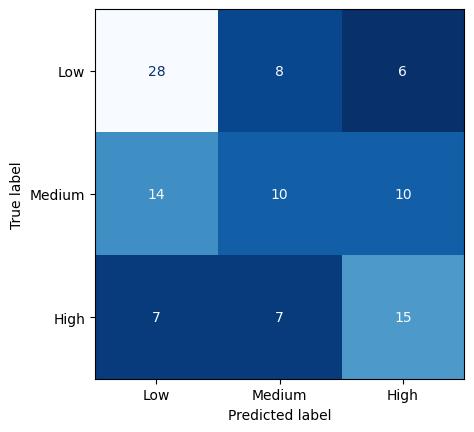

In [38]:
import matplotlib as plt
from sklearn.metrics import ConfusionMatrixDisplay

cmap = "Blues_r"
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ['Low', 'Medium', 'High'])
disp.plot(cmap = cmap, colorbar = False)